Импорты:

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    classification_report, roc_curve
)

np.random.seed(42)

In [2]:
!pip install catboost vowpalwabbit scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 5.1 MB/s eta 0:00:00


Подготовка признаков и разбиение данных на train / val / test:

In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Справочник услуг
profiles = {
    "Общий анализ крови": ["Гемоглобин", "Лейкоциты", "Тромбоциты"],
    "Биохимия":           ["АЛТ", "АСТ", "Креатинин"],
    "Гормоны":            ["ТТГ", "Т4 свободный", "Кортизол"],
    "Аллергология":       ["IgE общий", "Аллерген кошек", "Аллерген пыльцы"],
    "Коагулограмма":      ["АЧТВ", "Протромбиновое время", "Фибриноген"],
}

all_services = [(profile, svc)
                for profile, svcs in profiles.items()
                for svc in svcs]

N_PATIENTS = 2000
AGE_GROUPS = ["18-30", "31-45", "46-60", "60+"]
GENDERS = ["М", "Ж"]
CITIES = ["Москва", "СПб", "Казань", "Новосибирск", "Екатеринбург"]

# Ниже задаются зависимости, которые будут влиять на вероятность выбора услуги

# Возраст влияет на то, к каким профилям пациент чаще склоняется
age_profile_affinity = {
    "18-30":  {"Аллергология": 0.30, "Гормоны": 0.20, "Общий анализ крови": 0.05, "Биохимия": 0.00, "Коагулограмма": 0.00},
    "31-45":  {"Аллергология": 0.15, "Гормоны": 0.15, "Общий анализ крови": 0.10, "Биохимия": 0.10, "Коагулограмма": 0.05},
    "46-60":  {"Аллергология": 0.00, "Гормоны": 0.05, "Общий анализ крови": 0.10, "Биохимия": 0.20, "Коагулограмма": 0.15},
    "60+":    {"Аллергология": 0.00, "Гормоны": 0.00, "Общий анализ крови": 0.10, "Биохимия": 0.25, "Коагулограмма": 0.30},
}

# Небольшой сдвиг по профилям в зависимости от города
city_profile_affinity = {
    "Москва":       {"Гормоны": 0.10, "Аллергология": 0.10},
    "СПб":          {"Биохимия": 0.10, "Коагулограмма": 0.05},
    "Казань":       {"Общий анализ крови": 0.10},
    "Новосибирск":  {"Коагулограмма": 0.10},
    "Екатеринбург": {"Биохимия": 0.10, "Общий анализ крови": 0.05},
}

# Пол тоже немного влияет на предпочтения
gender_profile_affinity = {
    "Ж": {"Гормоны": 0.15, "Аллергология": 0.05},
    "М": {"Биохимия": 0.05, "Коагулограмма": 0.05},
}


def compute_probability(age, gender, city, profile, n_same, n_total):

    base = 0.03

    # Эффект усиливается, если в том же профиле уже есть выбранные услуги
    if n_same == 0:
        complement_boost = 0.0
    elif n_same == 1:
        complement_boost = 0.10
    else:  # при двух и более услугах в профиле прибавка становится заметно выше
        complement_boost = 0.45

    # Поправка на возрастную группу
    age_boost = age_profile_affinity.get(age, {}).get(profile, 0.0)

    # Поправка на город
    city_boost = city_profile_affinity.get(city, {}).get(profile, 0.0)

    # Поправка на пол
    gender_boost = gender_profile_affinity.get(gender, {}).get(profile, 0.0)

    # Чем больше услуг уже выбрано, тем выше активность пациента, но рост не линейный
    activity_boost = 0.05 * np.log1p(n_total)

    # Для старших групп связь внутри профиля дополнительно усиливается
    if age in ("46-60", "60+") and n_same >= 2:
        synergy = 0.10
    else:
        synergy = 0.0

    prob = base + complement_boost + age_boost + city_boost + gender_boost + activity_boost + synergy
    return np.clip(prob, 0.01, 0.92)


rows = []
for pid in range(N_PATIENTS):
    age = np.random.choice(AGE_GROUPS)
    gender = np.random.choice(GENDERS)
    city = np.random.choice(CITIES)

    n_taken = np.random.randint(1, 8)
    taken_indices = np.random.choice(len(all_services), size=n_taken, replace=False)
    taken_set = {all_services[i][1] for i in taken_indices}
    taken_profiles = [all_services[i][0] for i in taken_indices]

    for profile, svc in all_services:
        if svc in taken_set:
            continue

        n_same_profile = sum(1 for p in taken_profiles if p == profile)
        has_related = int(n_same_profile > 0)

        prob = compute_probability(age, gender, city, profile,
                                   n_same_profile, n_taken)
        target = int(np.random.rand() < prob)

        rows.append({
            "patient_id": pid,
            "age_group": age,
            "gender": gender,
            "city": city,
            "profile": profile,
            "candidate_service": svc,
            "n_services_total": n_taken,
            "n_services_same_profile": n_same_profile,
            "has_related": has_related,
            "target": target,
        })

df = pd.DataFrame(rows)
print(f"Размер датасета: {df.shape}")
print(f"\nБаланс классов:")
print(df["target"].value_counts(normalize=True).to_string())
print(f"\nПервые строки:")
print(df.head(6).to_string())

Размер датасета: (22080, 10)

Баланс классов:
target
0    0.660236
1    0.339764

Первые строки:
   patient_id age_group gender          city             profile candidate_service  n_services_total  n_services_same_profile  has_related  target
0           0     46-60      Ж  Екатеринбург  Общий анализ крови        Тромбоциты                 7                        2            1       1
1           0     46-60      Ж  Екатеринбург            Биохимия               АСТ                 7                        2            1       1
2           0     46-60      Ж  Екатеринбург             Гормоны               ТТГ                 7                        1            1       0
3           0     46-60      Ж  Екатеринбург             Гормоны      Т4 свободный                 7                        1            1       1
4           0     46-60      Ж  Екатеринбург        Аллергология         IgE общий                 7                        1            1       0
5           0     46-

In [4]:
FEATURE_COLS = ["age_group", "gender", "city", "profile",
                "candidate_service", "n_services_total",
                "n_services_same_profile", "has_related"]
CAT_COLS = ["age_group", "gender", "city", "profile", "candidate_service"]

X = df[FEATURE_COLS]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 14131, Val: 3533, Test: 4416


EDA - распределение ключевого признака и доля положительных примеров:

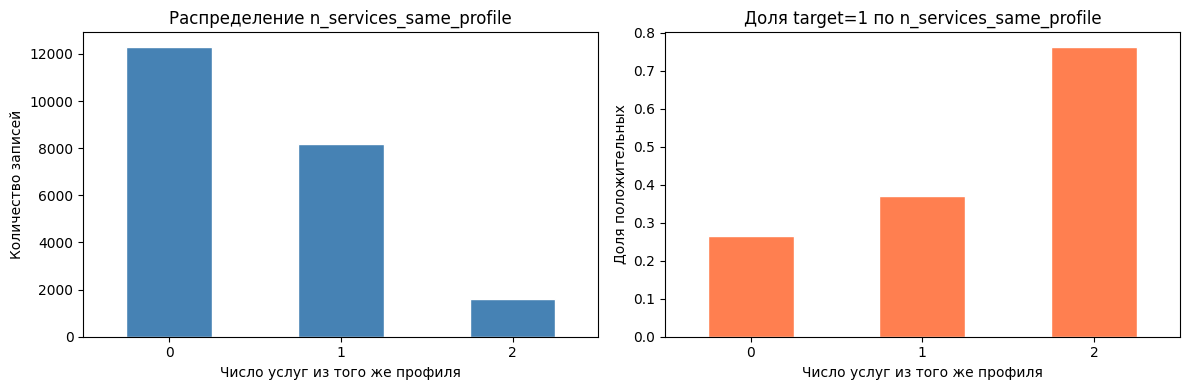

      age_group gender          city             profile candidate_service  n_services_total  n_services_same_profile  has_related  target
19441     18-30      М        Казань        Аллергология   Аллерген пыльцы                 3                        0            0       0
7861        60+      Ж        Москва            Биохимия               АСТ                 3                        0            0       0
2748      18-30      М  Екатеринбург  Общий анализ крови         Лейкоциты                 4                        1            1       0
7462      46-60      М  Екатеринбург  Общий анализ крови        Тромбоциты                 2                        1            1       0
4269      46-60      Ж           СПб       Коагулограмма              АЧТВ                 6                        2            1       1
3860      31-45      Ж   Новосибирск             Гормоны      Т4 свободный                 1                        0            0       1
11952     18-30      М   Но

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение по числу услуг из того же профиля
df["n_services_same_profile"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Распределение n_services_same_profile")
axes[0].set_xlabel("Число услуг из того же профиля")
axes[0].set_ylabel("Количество записей")
axes[0].tick_params(axis='x', rotation=0)

# Доля положительных примеров для каждого значения признака
target_rate = df.groupby("n_services_same_profile")["target"].mean()
target_rate.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Доля target=1 по n_services_same_profile")
axes[1].set_xlabel("Число услуг из того же профиля")
axes[1].set_ylabel("Доля положительных")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig("eda_rec.png", dpi=150)
plt.show()

# 10 случайных строк
print(df[["age_group","gender","city","profile","candidate_service",
          "n_services_total","n_services_same_profile","has_related","target"]]
      .sample(10, random_state=42).to_string())

Обучение модели CatBoost:

In [6]:
from catboost import CatBoostClassifier, Pool

cat_indices = [X_train.columns.get_loc(c) for c in CAT_COLS]

train_pool = Pool(X_train, y_train, cat_features=cat_indices)
val_pool   = Pool(X_val,   y_val,   cat_features=cat_indices)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_indices)

cb_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
)

start_cb = time.time()
cb_model.fit(train_pool, eval_set=val_pool, use_best_model=True)
time_cb = time.time() - start_cb

0:	test: 0.6163877	best: 0.6163877 (0)	total: 108ms	remaining: 54s
100:	test: 0.7186523	best: 0.7186523 (100)	total: 4.91s	remaining: 19.4s
200:	test: 0.7236375	best: 0.7236375 (200)	total: 8.54s	remaining: 12.7s
300:	test: 0.7245353	best: 0.7248225 (295)	total: 10.4s	remaining: 6.85s
400:	test: 0.7249714	best: 0.7249820 (376)	total: 12.2s	remaining: 3.02s
499:	test: 0.7247255	best: 0.7252332 (411)	total: 14.8s	remaining: 0us

bestTest = 0.7252332476
bestIteration = 411

Shrink model to first 412 iterations.


In [7]:
cb_proba = cb_model.predict_proba(X_test)[:, 1]
cb_pred  = cb_model.predict(X_test)

print("Результаты по CatBoost")
print(f"AUC:       {roc_auc_score(y_test, cb_proba):.4f}")
print(f"F1:        {f1_score(y_test, cb_pred):.4f}")
print(f"Precision: {precision_score(y_test, cb_pred):.4f}")
print(f"Recall:    {recall_score(y_test, cb_pred):.4f}")
print(f"Время обучения: {time_cb:.2f} с")
print(f"\n{classification_report(y_test, cb_pred)}")

Результаты по CatBoost
AUC:       0.7089
F1:        0.4070
Precision: 0.6477
Recall:    0.2967
Время обучения: 14.95 с

              precision    recall  f1-score   support

           0       0.72      0.92      0.80      2916
           1       0.65      0.30      0.41      1500

    accuracy                           0.71      4416
   macro avg       0.68      0.61      0.61      4416
weighted avg       0.69      0.71      0.67      4416



Важность признаков CatBoost:

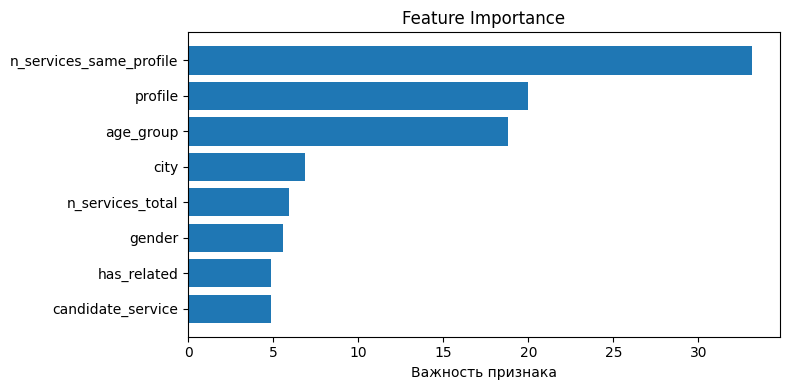

In [8]:
feat_imp = cb_model.get_feature_importance(train_pool)
feat_names = X_train.columns

plt.figure(figsize=(8, 4))
sorted_idx = np.argsort(feat_imp)
plt.barh(feat_names[sorted_idx], feat_imp[sorted_idx])
plt.xlabel("Важность признака")
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig("catboost_feature_importance.png", dpi=150)
plt.show()

Обучение модели Vowpal Wabbit:

In [17]:
import vowpalwabbit
import scipy.special


def to_vw_line(row, label):
    # Преобразование строки в формат VW
    lbl = 1 if label == 1 else -1
    # Категориальные признаки записываем как бинарные
    cat_ns = (
        f"age_{row['age_group'].replace(' ', '_')}:1 "
        f"gender_{row['gender']}:1 "
        f"city_{row['city']}:1 "
        f"profile_{row['profile'].replace(' ', '_')}:1 "
        f"svc_{row['candidate_service'].replace(' ', '_')}:1"
    )
    # Числовые признаки оставляем в явном виде
    num_ns = (
        f"n_total:{row['n_services_total']} "
        f"n_same:{row['n_services_same_profile']} "
        f"has_rel:{row['has_related']}"
    )
    return f"{lbl} |cat {cat_ns} |num {num_ns}"


vw = vowpalwabbit.Workspace(
    "--loss_function logistic --bit_precision 20 "
    "--quadratic cn --quadratic cc "
    "--l2 1e-6 --passes 10 --cache_file /tmp/vw_cache.tmp --quiet"
)

# Обучение модели
start_vw = time.time()
for idx in X_train.index:
    line = to_vw_line(X_train.loc[idx], y_train[idx])
    vw.learn(line)
time_vw = time.time() - start_vw

# Считаем предсказания на тесте
vw_raw_preds = []
for idx in X_test.index:
    line = to_vw_line(X_test.loc[idx], y_test[idx])
    raw = vw.predict(line)
    vw_raw_preds.append(raw)

vw.finish()

# Перевод raw-оценки в вероятности
vw_proba = scipy.special.expit(np.array(vw_raw_preds))
vw_pred  = (vw_proba >= 0.5).astype(int)

In [18]:
print("Результаты VW")
print(f"AUC:       {roc_auc_score(y_test, vw_proba):.4f}")
print(f"F1:        {f1_score(y_test, vw_pred):.4f}")
print(f"Precision: {precision_score(y_test, vw_pred):.4f}")
print(f"Recall:    {recall_score(y_test, vw_pred):.4f}")
print(f"Время обучения: {time_vw:.2f} с")
print(f"\n{classification_report(y_test, vw_pred)}")

Результаты VW
AUC:       0.6957
F1:        0.4204
Precision: 0.6053
Recall:    0.3220
Время обучения: 3.79 с

              precision    recall  f1-score   support

           0       0.72      0.89      0.80      2916
           1       0.61      0.32      0.42      1500

    accuracy                           0.70      4416
   macro avg       0.66      0.61      0.61      4416
weighted avg       0.68      0.70      0.67      4416



Сводная таблица результатов:

In [22]:
results = pd.DataFrame({
    "Метрика": ["AUC", "F1", "Precision", "Recall", "Время обучения (с)"],
    "CatBoost": [
        roc_auc_score(y_test, cb_proba),
        f1_score(y_test, cb_pred),
        precision_score(y_test, cb_pred),
        recall_score(y_test, cb_pred),
        time_cb,
    ],
    "Vowpal Wabbit": [
        roc_auc_score(y_test, vw_proba),
        f1_score(y_test, vw_pred),
        precision_score(y_test, vw_pred),
        recall_score(y_test, vw_pred),
        time_vw,
    ],
})
results["CatBoost"] = results["CatBoost"].apply(lambda x: f"{x:.4f}")
results["Vowpal Wabbit"] = results["Vowpal Wabbit"].apply(lambda x: f"{x:.4f}")

print("Сводная таблица:")
print(results.to_string(index=False))

Сводная таблица:
           Метрика CatBoost Vowpal Wabbit
               AUC   0.7089        0.6957
                F1   0.4070        0.4204
         Precision   0.6477        0.6053
            Recall   0.2967        0.3220
Время обучения (с)  14.9518        3.7895


ROC-кривые:

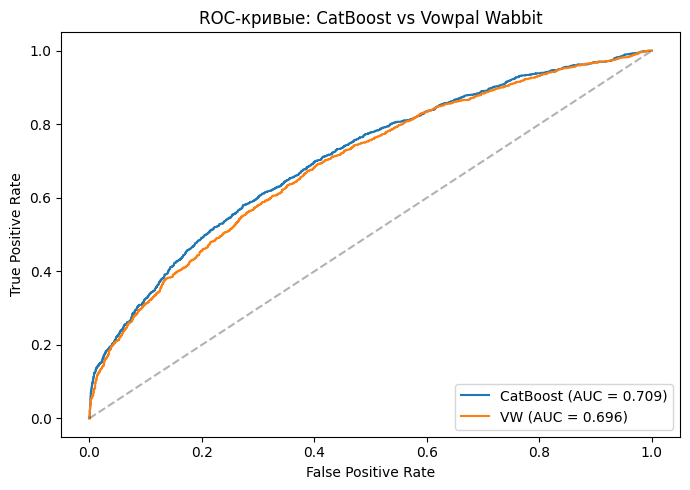

In [23]:
fpr_cb, tpr_cb, _ = roc_curve(y_test, cb_proba)
fpr_vw, tpr_vw, _ = roc_curve(y_test, vw_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr_cb, tpr_cb,
         label=f"CatBoost (AUC = {roc_auc_score(y_test, cb_proba):.3f})")
plt.plot(fpr_vw, tpr_vw,
         label=f"VW (AUC = {roc_auc_score(y_test, vw_proba):.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые: CatBoost vs Vowpal Wabbit")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("roc_comparison.png", dpi=150)
plt.show()

Пример рекомендаций для отдельного пациента:

In [24]:
# Берём одного пациента для примера
PID = 0

# Список услуг, которые у него уже есть
patient_data = df[df["patient_id"] == PID]
taken = set(
    [(p, s) for p, s in all_services]
) - set(
    zip(patient_data["profile"], patient_data["candidate_service"])
)
print("Уже сдал:")
for profile, svc in sorted(taken):
    print(f"  [{profile}] {svc}")

# Получаем оценки для всех доступных вариантов
patient_test = patient_data[FEATURE_COLS]
patient_proba = cb_model.predict_proba(patient_test)[:, 1]

recommendations = (
    pd.DataFrame({
        "profile": patient_data["profile"].values,
        "service": patient_data["candidate_service"].values,
        "n_same_profile": patient_data["n_services_same_profile"].values,
        "score": patient_proba
    })
    .sort_values("score", ascending=False)
)

print(f"Топ-5 рекомендаций:")
print(recommendations.head(5).to_string(index=False))

Уже сдал:
  [Аллергология] Аллерген пыльцы
  [Биохимия] АЛТ
  [Биохимия] Креатинин
  [Гормоны] Кортизол
  [Коагулограмма] Протромбиновое время
  [Общий анализ крови] Гемоглобин
  [Общий анализ крови] Лейкоциты
Топ-5 рекомендаций:
           profile    service  n_same_profile    score
          Биохимия        АСТ               2 0.899959
Общий анализ крови Тромбоциты               2 0.817263
     Коагулограмма Фибриноген               1 0.394171
     Коагулограмма       АЧТВ               1 0.382911
           Гормоны        ТТГ               1 0.378979
